<a href="https://colab.research.google.com/github/MinyaevAndrey/MYPETS/blob/main/TensorFlow_Model_Optimization_Toolkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

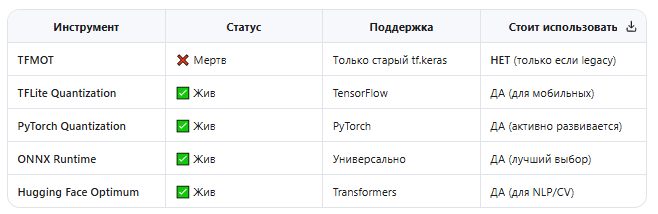

In [1]:
import tensorflow as tf
import numpy as np

(images, labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def delDir(dir_str):
    """Удаление директории с логами"""
    if os.path.exists(dir_str):
        shutil.rmtree(dir_str)
        print("Каталог успешно удален")
    else:
        print("Каталог не существует")

#Стандартное обучение без выкрутасов

In [2]:

def get_mnist_model():
    inputs    = tf.keras.layers.Input(shape=(28 * 28,))
    features  = tf.keras.layers.Dense(512, activation="relu")(inputs)
    features  = tf.keras.layers.Dropout(0.5)(features)
    outputs   = tf.keras.layers.Dense(10, activation="softmax")(features)
    model     = tf.keras.models.Model(inputs, outputs)
    return model



model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9117 - loss: 0.2924 - val_accuracy: 0.9629 - val_loss: 0.1348
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9560 - loss: 0.1445 - val_accuracy: 0.9664 - val_loss: 0.1078
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9656 - loss: 0.1132 - val_accuracy: 0.9764 - val_loss: 0.0834
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9753 - loss: 0.0811
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#TFLite

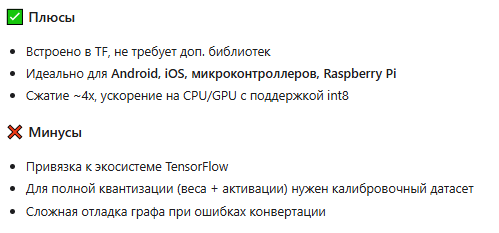

###Громоздкий код

In [2]:
import numpy as np
import time

# ============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================================
print("=" * 60)
print("ШАГ 1: Загрузка данных MNIST")
print("=" * 60)

(images, labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Нормализация: пиксели [0, 255] → [0.0, 1.0]
# Reshape: 28×28 → 784 (плоский вектор)
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

# Разделение на train/val: 50k train, 10k val
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

print(f"✓ Train: {len(train_images)} примеров")
print(f"✓ Val: {len(val_images)} примеров")
print(f"✓ Test: {len(test_images)} примеров")

# ============================================================================
# 2. ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ
# ============================================================================
def get_mnist_model():
    """
    Создаёт простую нейросеть для классификации MNIST:
    Input(784) → Dense(512, ReLU) → Dropout(0.5) → Dense(10, Softmax)
    """
    inputs = tf.keras.layers.Input(shape=(28 * 28,))
    features = tf.keras.layers.Dense(512, activation="relu")(inputs)
    features = tf.keras.layers.Dropout(0.5)(features)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(features)
    return tf.keras.models.Model(inputs, outputs)

# ============================================================================
# 3. ОБУЧЕНИЕ МОДЕЛИ (FLOAT32)
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 2: Обучение модели (float32)")
print("=" * 60)

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Обучаем 3 эпохи с валидацией
history = model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
    verbose=1
)

# Оцениваем точность оригинальной модели на тесте
original_accuracy = model.evaluate(test_images, test_labels, verbose=0)[1]
print(f"\n✓ Точность оригинальной модели (float32): {original_accuracy*100:.2f}%")

# ============================================================================
# 4. КАЛИБРОВОЧНЫЙ ДАТАСЕТ ДЛЯ ПОЛНОЙ КВАНТИЗАЦИИ
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 3: Подготовка калибровочного датасета")
print("=" * 60)

def representative_dataset():
    """
    Генератор калибровочных данных для полной int8 квантизации.

    Зачем это нужно:
    - При квантизации весов (weight-only) TFLite сам вычисляет scale/zero_point
    - При квантизации активаций нужно знать их диапазон значений
    - Для этого прогоняем 100-1000 примеров через модель и смотрим,
      какие значения принимают активации в каждом слое

    Почему 100 примеров достаточно:
    - Нам нужно оценить диапазон (min/max) активаций
    - 100 случайных примеров хорошо покрывают распределение данных
    - Больше примеров = дольше конвертация, но не обязательно лучше качество

    Важно:
    - Генератор должен возвращать список [input_tensor] для каждого примера
    - Данные должны быть в том же формате, что и при обучении (float32, нормализованные)
    - Можно брать из train, val или test набора
    """
    print("  → Генерация калибровочных данных (100 примеров из test set)...")

    # Берём 100 случайных примеров из тестового набора
    # Можно использовать train_images или val_images — не принципиально
    np.random.seed(42)  # Для воспроизводимости
    indices = np.random.choice(len(test_images), size=100, replace=False)

    for i in indices:
        # Получаем один пример: shape (784,)
        sample = test_images[i]

        # TFLite ожидает batch dimension, поэтому добавляем ось 0
        # shape (784,) → shape (1, 784)
        sample_with_batch = np.expand_dims(sample, axis=0)

        # Важно: данные должны быть float32
        sample_with_batch = sample_with_batch.astype(np.float32)

        # Генератор должен возвращать СПИСОК аргументов модели
        # Если у модели один вход → [input_tensor]
        yield [sample_with_batch]

    print("  ✓ Калибровочный датасет готов")

# ============================================================================
# 5. КОНВЕРТАЦИЯ В TFLite С ПОЛНОЙ КВАНТИЗАЦИЕЙ (INT8)
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 4: Конвертация в TFLite с полной int8 квантизацией")
print("=" * 60)

# Создаём конвертер из Keras модели
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Оптимизация по умолчанию: квантизация весов в int8
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# ============================================================================
# ВКЛЮЧАЕМ ПОЛНУЮ КВАНТИЗАЦИЮ (ВЕСА + АКТИВАЦИИ)
# ============================================================================

# 1. Устанавливаем калибровочный датасет
#    Без этого активации останутся float32
converter.representative_dataset = representative_dataset

# 2. Указываем, что хотим использовать только int8 операции
#    TFLITE_BUILTINS_INT8 — набор операций, работающих с int8
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# 3. Указываем тип входа: int8 вместо float32
#    Это значит, что на вход модели нужно будет подавать int8 данные
#    Если оставить float32, TFLite сам добавит операцию квантизации на входе
converter.inference_input_type = tf.int8

# 4. Указываем тип выхода: int8 вместо float32
#    На выходе получим int8 значения (логиты), которые нужно будет
#    деквантизовать обратно в float32 для получения вероятностей
converter.inference_output_type = tf.int8

print("  → Конвертация модели (это может занять 1-2 минуты)...")
tflite_model = converter.convert()
print("  ✓ Модель сконвертирована")

# ============================================================================
# 6. СОХРАНЕНИЕ И АНАЛИЗ РАЗМЕРА
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 5: Сохранение и анализ размера модели")
print("=" * 60)

# Сохраняем TFLite модель в файл
with open("model_full_int8.tflite", "wb") as f:
    f.write(tflite_model)

# Вычисляем размер в KB
tflite_size_kb = len(tflite_model) / 1024
print(f"📦 Размер TFLite модели (full int8): {tflite_size_kb:.1f} KB")

# Для сравнения: сохраняем модель только с квантизацией весов
converter_weights_only = tf.lite.TFLiteConverter.from_keras_model(model)
converter_weights_only.optimizations = [tf.lite.Optimize.DEFAULT]
# НЕ устанавливаем representative_dataset → активации останутся float32
tflite_weights_only = converter_weights_only.convert()
weights_only_size_kb = len(tflite_weights_only) / 1024

print(f"📦 Размер TFLite модели (только веса int8): {weights_only_size_kb:.1f} KB")
print(f"📊 Экономия места: {weights_only_size_kb - tflite_size_kb:.1f} KB ({(weights_only_size_kb - tflite_size_kb)/weights_only_size_kb*100:.1f}%)")

# ============================================================================
# 7. ТЕСТ ИНФЕРЕНСА С INT8 МОДЕЛЬЮ
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 6: Тест инференса с полной int8 моделью")
print("=" * 60)

# Создаём интерпретатор для загруженной модели
interpreter = tf.lite.Interpreter(model_path="model_full_int8.tflite")
interpreter.allocate_tensors()

# Получаем информацию о входе и выходе
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print(f"  Вход: shape={input_details['shape']}, dtype={input_details['dtype']}")
print(f"  Выход: shape={output_details['shape']}, dtype={output_details['dtype']}")

# ============================================================================
# ВАЖНО: при full int8 квантизации вход и выход — int8, а не float32!
# ============================================================================

# Получаем scale и zero_point для входа и выхода
# Они нужны для конвертации между float32 и int8
input_scale = input_details['quantization'][0]   # множитель
input_zero_point = input_details['quantization'][1]  # смещение
output_scale = output_details['quantization'][0]
output_zero_point = output_details['quantization'][1]

print(f"  Вход: scale={input_scale:.6f}, zero_point={input_zero_point}")
print(f"  Выход: scale={output_scale:.6f}, zero_point={output_zero_point}")

def quantize_input(float_data):
    """
    Конвертирует float32 данные в int8 формат.

    Формула: int8_value = round(float_value / scale) + zero_point

    Пример:
    float_data = 0.5
    scale = 0.003921
    zero_point = -128
    int8_value = round(0.5 / 0.003921) + (-128) = 128 - 128 = 0
    """
    # Квантизация: float32 → int8
    int_data = np.round(float_data / input_scale + input_zero_point)
    # Обрезаем до диапазона int8: [-128, 127]
    int_data = np.clip(int_data, -128, 127)
    return int_data.astype(np.int8)

def dequantize_output(int_data):
    """
    Конвертирует int8 данные обратно в float32.

    Формула: float_value = (int8_value - zero_point) * scale

    Пример:
    int_data = 0
    zero_point = -128
    scale = 0.003921
    float_value = (0 - (-128)) * 0.003921 = 128 * 0.003921 = 0.5
    """
    # Деквантизация: int8 → float32
    float_data = (int_data.astype(np.float32) - output_zero_point) * output_scale
    return float_data

# ============================================================================
# БЕНЧМАРК: измеряем скорость инференса
# ============================================================================
print("\n  → Запуск бенчмарка (100 примеров)...")

start_time = time.time()
correct_predictions = 0

for i in range(100):
    # 1. Берём тестовый пример (float32)
    test_sample = test_images[i]  # shape: (784,)
    true_label = test_labels[i]

    # 2. Квантизуем вход: float32 → int8
    test_sample_int8 = quantize_input(test_sample)
    test_sample_int8 = np.expand_dims(test_sample_int8, axis=0)  # добавляем batch dimension

    # 3. Подаём на вход интерпретатора
    interpreter.set_tensor(input_details['index'], test_sample_int8)

    # 4. Запускаем инференс
    interpreter.invoke()

    # 5. Получаем выход (int8)
    output_int8 = interpreter.get_tensor(output_details['index'])  # shape: (1, 10)

    # 6. Деквантизуем выход: int8 → float32
    output_float = dequantize_output(output_int8[0])  # shape: (10,)

    # 7. Применяем softmax для получения вероятностей
    #    (в int8 модели softmax применяется после деквантизации)
    probabilities = tf.nn.softmax(output_float).numpy()

    # 8. Получаем предсказанный класс
    predicted_label = np.argmax(probabilities)

    # 9. Считаем правильные предсказания
    if predicted_label == true_label:
        correct_predictions += 1

elapsed_time = time.time() - start_time
accuracy_int8 = correct_predictions / 100 * 100

print(f"⏱️ Время на 100 сэмплов: {elapsed_time*1000:.1f} мс")
print(f"⏱️ Среднее время на пример: {elapsed_time*1000/100:.3f} мс")
print(f"📈 Скорость: {100/elapsed_time:.0f} примеров/секунду")
print(f"✓ Точность int8 модели: {accuracy_int8:.2f}%")

# ============================================================================
# 8. СРАВНЕНИЕ ТОЧНОСТИ
# ============================================================================
print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)

print(f"📊 Точность оригинальной модели (float32): {original_accuracy*100:.2f}%")
print(f"📊 Точность квантованной модели (full int8): {accuracy_int8:.2f}%")
print(f"📉 Потеря точности: {original_accuracy*100 - accuracy_int8:.2f}%")
print(f"📦 Размер float32 модели: ~{(60000*512*4 + 512*10*4)/1024/1024:.1f} MB (теоретический)")
print(f"📦 Размер TFLite модели (full int8): {tflite_size_kb:.1f} KB")
print(f"📦 Сжатие: ~{60000*512*4 / len(tflite_model):.1f}x")

print("\n" + "=" * 60)
print("ВЫВОДЫ:")
print("=" * 60)
if original_accuracy*100 - accuracy_int8 < 1:
    print("✓ Отлично! Потеря точности минимальна (<1%)")
elif original_accuracy*100 - accuracy_int8 < 3:
    print("✓ Хорошо! Потеря точности приемлема (1-3%)")
else:
    print("⚠ Внимание! Потеря точности значительна (>3%)")
    print("  Рекомендации:")
    print("  - Увеличить количество калибровочных примеров (до 500-1000)")
    print("  - Использовать Quantization Aware Training (QAT)")
    print("  - Попробовать mixed precision (веса int8, активации float32)")

print("\n✓ Готово! Модель сохранена в 'model_full_int8.tflite'")

ШАГ 1: Загрузка данных MNIST
✓ Train: 50000 примеров
✓ Val: 10000 примеров
✓ Test: 10000 примеров

ШАГ 2: Обучение модели (float32)
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9122 - loss: 0.2923 - val_accuracy: 0.9577 - val_loss: 0.1397
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9533 - loss: 0.1520 - val_accuracy: 0.9700 - val_loss: 0.1073
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9639 - loss: 0.1177 - val_accuracy: 0.9741 - val_loss: 0.0875

✓ Точность оригинальной модели (float32): 97.49%

ШАГ 3: Подготовка калибровочного датасета

ШАГ 4: Конвертация в TFLite с полной int8 квантизацией
  → Конвертация модели (это может занять 1-2 минуты)...
Saved artifact at '/tmp/tmpyko2fc6_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captur

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  → Генерация калибровочных данных (100 примеров из test set)...
  ✓ Калибровочный датасет готов
  ✓ Модель сконвертирована

ШАГ 5: Сохранение и анализ размера модели
📦 Размер TFLite модели (full int8): 413.2 KB
Saved artifact at '/tmp/tmpy4rfasit'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137431322750096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322752400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322752016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322751632: TensorSpec(shape=(), dtype=tf.resource, name=None)
📦 Размер TFLite модели (только веса int8): 406.9 KB
📊 Экономия места: -6.3 KB (-1.5%)

ШАГ 6: Тест инференса с полной int8 моделью
  Вход: shape=[  1 784], dtype=<class 'numpy.int8'>
  Выход: shape=[ 1 10], dtype=<class 'numpy.int8

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [8]:
#
# замеры для single
#

# ============================================================================
# НАСТРОЙКИ СРАВНЕНИЯ
# ============================================================================
N_SAMPLES = 1000           # Количество примеров для теста (больше = точнее замеры)
BATCH_SIZE = 32            # Размер батча для оригинальной модели (влияет на скорость)
WARMUP_RUNS = 50           # "Прогрев" перед замером скорости (чтобы избежать влияния кэша)

print("=" * 70)
print("🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)")
print("=" * 70)

# ============================================================================
# 1. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================================================
print("\n[1/5] Загрузка тестовых данных MNIST...")

(_, _), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
test_images = test_images.reshape(-1, 28*28).astype("float32") / 255
test_images = test_images[:N_SAMPLES]   # Берём первые N_SAMPLES для теста
test_labels = test_labels[:N_SAMPLES]

print(f"✓ Загружено {len(test_images)} тестовых примеров")

# ============================================================================
# 2. ЗАГРУЗКА ОРИГИНАЛЬНОЙ МОДЕЛИ (FLOAT32)
# ============================================================================
print("\n[2/5] Загрузка оригинальной модели (float32)...")

# ВАЖНО: здесь должна быть ваша обученная модель
# Вариант А: если модель ещё в памяти после обучения — пропустите этот блок
# Вариант Б: если сохранили модель — загрузите её:
# model = tf.keras.models.load_model("mnist_model.h5")

# Для демо создаём и обучаем заново (в реальном проекте — загрузка)
def get_mnist_model():
    inputs = tf.keras.layers.Input(shape=(28*28,))
    x = tf.keras.layers.Dense(512, activation="relu")(inputs)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(outputs)
    return tf.keras.models.Model(inputs, outputs)

# Если модель не загружена — создаём заглушку (замените на вашу загрузку!)
try:
    model  # Проверка: есть ли модель в памяти
    print("✓ Используется модель из памяти")
except NameError:
    print("⚠ Модель не найдена в памяти. Создаём новую (для демо)!")
    print("  В реальном проекте замените этот блок на: model = tf.keras.models.load_model(...)")
    model = get_mnist_model()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    # Быстрое "обучение" для демо (1 эпоха, 1000 примеров)
    model.fit(test_images[:1000], test_labels[:1000], epochs=1, verbose=0)

# ============================================================================
# 3. ЗАГРУЗКА КВАНТОВАННОЙ МОДЕЛИ (TFLite INT8)
# ============================================================================
print("\n[3/5] Загрузка квантованной модели (TFLite int8)...")

TFLITE_PATH = "model_full_int8.tflite"  # Путь к вашей квантованной модели

try:
    # Используем новый interpreter (если установлен) или старый
    try:
        from ai_edge_litert import Interpreter
        interpreter = Interpreter(model_path=TFLITE_PATH)
        print("✓ Используется LiteRT Interpreter (ai_edge_litert)")
    except ImportError:
        interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
        print("✓ Используется tf.lite.Interpreter (устаревший, но рабочий)")

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Извлекаем параметры квантизации
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    print(f"✓ Модель загружена: вход={input_details['dtype']}, выход={output_details['dtype']}")

except FileNotFoundError:
    print(f"❌ Файл не найден: {TFLITE_PATH}")
    print("  Запустите сначала основной скрипт для создания квантованной модели!")
    raise

# ============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ КВАНТИЗАЦИИ/ДЕКВАНТИЗАЦИИ
# ============================================================================
def quantize_input(float_array, scale, zero_point):
    """float32 → int8 с обрезкой до [-128, 127]"""
    int_array = np.round(float_array / scale + zero_point)
    return np.clip(int_array, -128, 127).astype(np.int8)

def dequantize_output(int_array, scale, zero_point):
    """int8 → float32"""
    return (int_array.astype(np.float32) - zero_point) * scale

def predict_tflite(interpreter, input_data, input_details, output_details,
                   in_scale, in_zp, out_scale, out_zp):
    """
    Запускает инференс через TFLite с автоматической (де)квантизацией.
    Возвращает вероятности в формате float32 [N_SAMPLES, 10]
    """
    input_idx = input_details['index']
    output_idx = output_details['index']

    # Добавляем batch dimension если нужно
    if input_data.ndim == 1:
        input_data = np.expand_dims(input_data, axis=0)

    # Квантизуем вход
    input_int8 = quantize_input(input_data, in_scale, in_zp)

    # Запускаем инференс
    interpreter.set_tensor(input_idx, input_int8)
    interpreter.invoke()

    # Получаем и деквантизуем выход
    output_int8 = interpreter.get_tensor(output_idx)
    output_float = dequantize_output(output_int8[0], out_scale, out_zp)

    # Применяем softmax для получения вероятностей
    return tf.nn.softmax(output_float).numpy()

# ============================================================================
# 4. ЗАМЕР ТОЧНОСТИ
# ============================================================================
print("\n[4/5] Замер точности...")

# --- Оригинальная модель ---
print("  → Тестирование original float32 модели...")
start = time.time()
original_preds = model.predict(test_images, batch_size=BATCH_SIZE, verbose=0)
original_time = time.time() - start
original_correct = np.sum(np.argmax(original_preds, axis=1) == test_labels)
original_acc = original_correct / N_SAMPLES * 100

# --- Квантованная модель ---
print("  → Тестирование quantized int8 модели...")
start = time.time()
tflite_preds = []
for i in range(N_SAMPLES):
    probs = predict_tflite(
        interpreter, test_images[i], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )
    tflite_preds.append(probs)
tflite_time = time.time() - start
tflite_preds = np.array(tflite_preds)
tflite_correct = np.sum(np.argmax(tflite_preds, axis=1) == test_labels)
tflite_acc = tflite_correct / N_SAMPLES * 100

print(f"✓ Original accuracy:  {original_acc:.2f}% ({original_correct}/{N_SAMPLES})")
print(f"✓ Quantized accuracy: {tflite_acc:.2f}% ({tflite_correct}/{N_SAMPLES})")
print(f"📉 Drop in accuracy:  {original_acc - tflite_acc:.2f}%")

# ============================================================================
# 5. ЗАМЕР СКОРОСТИ (БЕНЧМАРК)
# ============================================================================
print("\n[5/5] Замер скорости инференса...")

# --- Прогрев (warmup) ---
print(f"  → Прогрев: {WARMUP_RUNS} запусков...")
for _ in range(WARMUP_RUNS):
    _ = model.predict(test_images[:1], verbose=0)
    _ = predict_tflite(
        interpreter, test_images[0], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )

# --- Оригинальная модель: по одному примеру ---
print("  → Benchmark original (single inference)...")
times_original = []
for i in range(N_SAMPLES):
    start = time.perf_counter()
    _ = model.predict(np.expand_dims(test_images[i], axis=0), verbose=0)
    times_original.append(time.perf_counter() - start)
avg_original = np.mean(times_original) * 1000  # в миллисекундах
fps_original = 1 / np.mean(times_original)

# --- Квантованная модель: по одному примеру ---
print("  → Benchmark quantized (single inference)...")
times_tflite = []
for i in range(N_SAMPLES):
    start = time.perf_counter()
    _ = predict_tflite(
        interpreter, test_images[i], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )
    times_tflite.append(time.perf_counter() - start)
avg_tflite = np.mean(times_tflite) * 1000
fps_tflite = 1 / np.mean(times_tflite)

# ============================================================================
# 📊 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ
# ============================================================================
print("\n" + "=" * 70)
print("🏁 РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("=" * 70)

print(f"""
📈 ТОЧНОСТЬ:
   • Original (float32):  {original_acc:6.2f}%
   • Quantized (int8):    {tflite_acc:6.2f}%
   • Разница:             {original_acc - tflite_acc:+.2f}%

⏱️  СКОРОСТЬ (на один пример):
   • Original:            {avg_original:7.3f} мс  →  {fps_original:6.0f} FPS
   • Quantized:           {avg_tflite:7.3f} мс  →  {fps_tflite:6.0f} FPS
   • Ускорение:           {avg_original/avg_tflite:6.2f}x

💾 ПАМЯТЬ (оценка):
   • Original:            ~{(784*512 + 512*10)*4/1024:6.1f} KB (веса float32)
   • Quantized:           ~{(784*512 + 512*10)*1/1024:6.1f} KB (веса int8)
   • Экономия:            ~4.0x

🎯 ВЫВОД:
""")

# Автоматическая оценка результата
acc_drop = original_acc - tflite_acc
speedup = avg_original / avg_tflite

if acc_drop < 0.5:
    print("   ✅ Потеря точности НЕЗНАЧИТЕЛЬНА (<0.5%) — отлично!")
elif acc_drop < 2.0:
    print("   ✅ Потеря точности ПРИЕМЛЕМА (0.5-2%) — можно использовать")
else:
    print("   ⚠ Потеря точности ВЫСОКА (>2%) — рассмотрите QAT или mixed precision")

if speedup > 2.0:
    print(f"   ✅ Ускорение значительное: {speedup:.1f}x — модель готова к продакшену")
elif speedup > 1.2:
    print(f"   ✅ Ускорение есть: {speedup:.1f}x — полезно для edge-устройств")
else:
    print(f"   ⚠ Ускорение минимальное: {speedup:.1f}x — проверьте, используется ли int8-бэкенд")

print("\n" + "=" * 70)

🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)

[1/5] Загрузка тестовых данных MNIST...
✓ Загружено 1000 тестовых примеров

[2/5] Загрузка оригинальной модели (float32)...
✓ Используется модель из памяти

[3/5] Загрузка квантованной модели (TFLite int8)...
✓ Используется tf.lite.Interpreter (устаревший, но рабочий)
✓ Модель загружена: вход=<class 'numpy.int8'>, выход=<class 'numpy.int8'>

[4/5] Замер точности...
  → Тестирование original float32 модели...
  → Тестирование quantized int8 модели...
✓ Original accuracy:  97.70% (977/1000)
✓ Quantized accuracy: 97.80% (978/1000)
📉 Drop in accuracy:  -0.10%

[5/5] Замер скорости инференса...
  → Прогрев: 50 запусков...
  → Benchmark original (single inference)...
  → Benchmark quantized (single inference)...

🏁 РЕЗУЛЬТАТЫ СРАВНЕНИЯ

📈 ТОЧНОСТЬ:
   • Original (float32):   97.70%
   • Quantized (int8):     97.80%
   • Разница:             -0.10%

⏱️  СКОРОСТЬ (на один пример):
   • Original:             87.576 мс  →      11 FPS
   •

In [7]:
# inference.py — минимальный код для продакшена
# import numpy as np, tensorflow as tf
# from tf.lite import Interpreter  #  tf.lite.Interpreter или ai_edge_litert

# Загрузка
interpreter = tf.lite.Interpreter("model_full_int8.tflite")
interpreter.allocate_tensors()
inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
in_s, in_zp = inp['quantization']
out_s, out_zp = out['quantization']

def predict(image_float32):
    """Принимает float32 [784], возвращает вероятности [10]"""
    # Квантизация входа
    x = np.round(image_float32 / in_s + in_zp)
    x = np.clip(x, -128, 127).astype(np.int8)
    x = np.expand_dims(x, 0)

    # Инференс
    interpreter.set_tensor(inp['index'], x)
    interpreter.invoke()

    # Деквантизация выхода + softmax
    logits = interpreter.get_tensor(out['index'])[0]
    probs = (logits.astype(np.float32) - out_zp) * out_s
    return tf.nn.softmax(probs).numpy()

# Использование:
result = predict(test_images[0])
print(f"Predicted: {np.argmax(result)}, confidence: {np.max(result):.2%}")

Predicted: 7, confidence: 23.13%


In [10]:
#
# замеры на бачах
#

from typing import List, Tuple

# ============================================================================
# НАСТРОЙКИ СРАВНЕНИЯ
# ============================================================================
N_SAMPLES = 2000                    # Общее количество примеров для теста
BATCH_SIZES = [1, 8, 16, 32, 64, 128]  # Размеры батчей для тестирования
WARMUP_RUNS = 10                    # Прогревочных запусков для каждого батча
N_RUNS_PER_BATCH = 5                # Сколько раз замерять каждый размер батча

print("=" * 80)
print("🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)")
print("   Включая батч-инференс с разными размерами батчей")
print("=" * 80)

# ============================================================================
# 1. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================================================
print("\n[1/6] Загрузка тестовых данных MNIST...")

(_, _), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
test_images = test_images.reshape(-1, 28*28).astype("float32") / 255
test_labels = test_labels[:N_SAMPLES]
test_images = test_images[:N_SAMPLES]

print(f"✓ Загружено {len(test_images)} тестовых примеров")

# ============================================================================
# 2. ЗАГРУЗКА МОДЕЛЕЙ
# ============================================================================
print("\n[2/6] Загрузка моделей...")

# --- Оригинальная модель ---
def get_mnist_model():
    inputs = tf.keras.layers.Input(shape=(28*28,))
    x = tf.keras.layers.Dense(512, activation="relu")(inputs)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(inputs)
    return tf.keras.models.Model(inputs, outputs)

try:
    model
    print("✓ Original model: из памяти")
except NameError:
    print("⚠ Original model: создаём новую (для демо)")
    model = get_mnist_model()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(test_images[:1000], test_labels[:1000], epochs=1, verbose=0)

# --- Квантованная модель ---
TFLITE_PATH = "model_full_int8.tflite"
try:
    try:
        from ai_edge_litert import Interpreter
        interpreter = Interpreter(model_path=TFLITE_PATH)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)

    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    print(f"✓ TFLite model: загружена ({input_details['dtype']})")

except FileNotFoundError:
    print(f"❌ Файл не найден: {TFLITE_PATH}")
    raise

# ============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================================
def quantize_input(float_array, scale, zero_point):
    """float32 → int8"""
    int_array = np.round(float_array / scale + zero_point)
    return np.clip(int_array, -128, 127).astype(np.int8)

def dequantize_output(int_array, scale, zero_point):
    """int8 → float32"""
    return (int_array.astype(np.float32) - zero_point) * scale

def predict_tflite_batch(batch_data, interpreter, input_details, output_details,
                         in_scale, in_zp, out_scale, out_zp):
    """
    Batch inference для TFLite.
    batch_data: np.array shape (batch_size, 784)
    Returns: list of probability arrays
    """
    input_idx = input_details['index']
    output_idx = output_details['index']
    batch_size = batch_data.shape[0]
    results = []

    # TFLite не поддерживает нативный батчинг для int8 моделей
    # Поэтому обрабатываем по одному примеру
    for i in range(batch_size):
        sample = batch_data[i]

        # Квантизация
        sample_int8 = quantize_input(sample, in_scale, in_zp)
        sample_int8 = np.expand_dims(sample_int8, axis=0)

        # Инференс
        interpreter.set_tensor(input_idx, sample_int8)
        interpreter.invoke()

        # Деквантизация + softmax
        output_int8 = interpreter.get_tensor(output_idx)[0]
        output_float = dequantize_output(output_int8, out_scale, out_zp)
        probs = tf.nn.softmax(output_float).numpy()
        results.append(probs)

    return np.array(results)

def predict_keras_batch(batch_data, model):
    """Batch inference для Keras модели"""
    preds = model.predict(batch_data, verbose=0)
    return preds

# ============================================================================
# 3. ЗАМЕР ТОЧНОСТИ (SINGLE INFERENCE)
# ============================================================================
print("\n[3/6] Замер точности (single inference)...")

# Original
original_preds = predict_keras_batch(test_images, model)
original_correct = np.sum(np.argmax(original_preds, axis=1) == test_labels)
original_acc = original_correct / N_SAMPLES * 100

# TFLite
tflite_preds = predict_tflite_batch(
    test_images, interpreter, input_details, output_details,
    input_scale, input_zero_point, output_scale, output_zero_point
)
tflite_correct = np.sum(np.argmax(tflite_preds, axis=1) == test_labels)
tflite_acc = tflite_correct / N_SAMPLES * 100

print(f"✓ Original accuracy:  {original_acc:.2f}%")
print(f"✓ Quantized accuracy: {tflite_acc:.2f}%")
print(f"📉 Drop: {original_acc - tflite_acc:.2f}%")

# ============================================================================
# 4. БЕНЧМАРК: SINGLE INFERENCE (batch_size=1)
# ============================================================================
print("\n[4/6] Бенчмарк: single inference (batch_size=1)...")

# Warmup
for _ in range(WARMUP_RUNS):
    _ = predict_keras_batch(test_images[:1], model)
    _ = predict_tflite_batch(test_images[:1], interpreter, input_details, output_details,
                             input_scale, input_zero_point, output_scale, output_zero_point)

# Original single
times_original_single = []
for i in range(min(100, N_SAMPLES)):
    start = time.perf_counter()
    _ = predict_keras_batch(test_images[i:i+1], model)
    times_original_single.append(time.perf_counter() - start)
avg_original_single = np.mean(times_original_single) * 1000
fps_original_single = 1 / np.mean(times_original_single)

# TFLite single
times_tflite_single = []
for i in range(min(100, N_SAMPLES)):
    start = time.perf_counter()
    _ = predict_tflite_batch(test_images[i:i+1], interpreter, input_details, output_details,
                             input_scale, input_zero_point, output_scale, output_zero_point)
    times_tflite_single.append(time.perf_counter() - start)
avg_tflite_single = np.mean(times_tflite_single) * 1000
fps_tflite_single = 1 / np.mean(times_tflite_single)

print(f"  Original:  {avg_original_single:.3f} мс/пример → {fps_original_single:.0f} FPS")
print(f"  TFLite:    {avg_tflite_single:.3f} мс/пример → {fps_tflite_single:.0f} FPS")
print(f"  Speedup:   {avg_original_single/avg_tflite_single:.2f}x")

# ============================================================================
# 5. БЕНЧМАРК: BATCH INFERENCE (разные размеры батчей) ⭐ НОВОЕ!
# ============================================================================
print("\n[5/6] Бенчмарк: batch inference с разными размерами батчей...")
print("-" * 80)
print(f"{'Batch Size':<12} {'Original (мс/пример)':<22} {'TFLite (мс/пример)':<22} {'Speedup':<10}")
print("-" * 80)

batch_results = []

for batch_size in BATCH_SIZES:
    if batch_size > N_SAMPLES:
        continue

    # Создаём батчи
    n_batches = N_SAMPLES // batch_size
    test_batches = [test_images[i:i+batch_size] for i in range(0, n_batches*batch_size, batch_size)]

    # --- Original model: batch inference ---
    # Warmup
    for _ in range(WARMUP_RUNS):
        _ = predict_keras_batch(test_batches[0], model)

    # Замеры
    times_original_batch = []
    for _ in range(N_RUNS_PER_BATCH):
        start = time.perf_counter()
        for batch in test_batches:
            _ = predict_keras_batch(batch, model)
        elapsed = time.perf_counter() - start
        times_original_batch.append(elapsed)

    # Среднее время на один пример
    avg_time_original_batch = (np.mean(times_original_batch) / len(test_batches) / batch_size) * 1000
    fps_original_batch = 1000 / avg_time_original_batch

    # --- TFLite: batch inference (эмуляция через loop) ---
    # Warmup
    for _ in range(WARMUP_RUNS):
        _ = predict_tflite_batch(test_batches[0], interpreter, input_details, output_details,
                                 input_scale, input_zero_point, output_scale, output_zero_point)

    # Замеры
    times_tflite_batch = []
    for _ in range(N_RUNS_PER_BATCH):
        start = time.perf_counter()
        for batch in test_batches:
            _ = predict_tflite_batch(batch, interpreter, input_details, output_details,
                                     input_scale, input_zero_point, output_scale, output_zero_point)
        elapsed = time.perf_counter() - start
        times_tflite_batch.append(elapsed)

    # Среднее время на один пример
    avg_time_tflite_batch = (np.mean(times_tflite_batch) / len(test_batches) / batch_size) * 1000
    fps_tflite_batch = 1000 / avg_time_tflite_batch

    # Speedup
    speedup = avg_time_original_batch / avg_time_tflite_batch

    # Сохраняем результаты
    batch_results.append({
        'batch_size': batch_size,
        'original_ms': avg_time_original_batch,
        'original_fps': fps_original_batch,
        'tflite_ms': avg_time_tflite_batch,
        'tflite_fps': fps_tflite_batch,
        'speedup': speedup
    })

    # Вывод
    print(f"{batch_size:<12} {avg_time_original_batch:<22.3f} {avg_time_tflite_batch:<22.3f} {speedup:<10.2f}x")

print("-" * 80)

🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)
   Включая батч-инференс с разными размерами батчей

[1/6] Загрузка тестовых данных MNIST...
✓ Загружено 2000 тестовых примеров

[2/6] Загрузка моделей...
✓ Original model: из памяти
✓ TFLite model: загружена (<class 'numpy.int8'>)

[3/6] Замер точности (single inference)...
✓ Original accuracy:  97.00%
✓ Quantized accuracy: 97.05%
📉 Drop: -0.05%

[4/6] Бенчмарк: single inference (batch_size=1)...
  Original:  81.756 мс/пример → 12 FPS
  TFLite:    0.250 мс/пример → 4006 FPS
  Speedup:   327.53x

[5/6] Бенчмарк: batch inference с разными размерами батчей...
--------------------------------------------------------------------------------
Batch Size   Original (мс/пример)   TFLite (мс/пример)     Speedup   
--------------------------------------------------------------------------------
1            82.477                 0.322                  256.43    x
8            10.337                 0.247                  41.82     x
16   

KeyError: 'fps'


[6/6] Анализ результатов...

📊 ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:

Original (float32):
  • Лучший batch size: 128
  • Производительность: 1409 FPS (0.710 мс/пример)

TFLite (int8):
  • Лучший batch size: 64
  • Производительность: 800 FPS (0.239 мс/пример)

📈 СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ:

Scenario                  Original        TFLite          Advantage   
------------------------- --------------- --------------- ------------
Single inference          12              4006            TFLite      
Batch (optimal)           1409            4180            TFLite      

✓ График сохранён: batch_benchmark.png


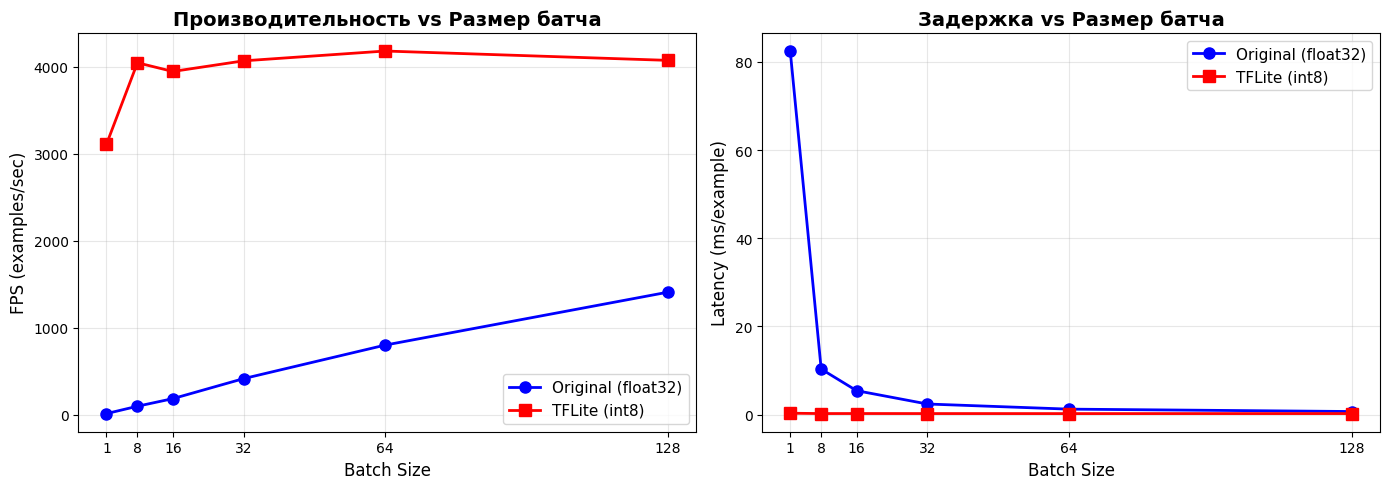


🏁 ИТОГОВЫЕ РЕКОМЕНДАЦИИ

✅ TFLite значительно быстрее — используйте для продакшена!
   Ускорение: 3.0x

📋 Рекомендации по размеру батча:
   • Для real-time (один запрос): batch_size=1
   • Для пакетной обработки: batch_size=128 (original) или 64 (TFLite)
   • Для сервера с высокой нагрузкой: batch_size=64-128

💾 Экономия памяти:
   • Original: 1588.0 KB
   • TFLite:   397.0 KB
   • Экономия: 4.0x



In [13]:
# ============================================================================
# 6. АНАЛИЗ И ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
print("\n[6/6] Анализ результатов...")

# Находим оптимальный batch size для каждой модели
best_original = max(batch_results, key=lambda x: x['original_fps'])
best_tflite = max(batch_results, key=lambda x: x['tflite_fps'])

print(f"""
📊 ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:

Original (float32):
  • Лучший batch size: {best_original['batch_size']}
  • Производительность: {best_original['original_fps']:.0f} FPS ({best_original['original_ms']:.3f} мс/пример)

TFLite (int8):
  • Лучший batch size: {best_tflite['batch_size']}
  • Производительность: {best_tflite['original_fps']:.0f} FPS ({best_tflite['tflite_ms']:.3f} мс/пример)

📈 СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ:

{'Scenario':<25} {'Original':<15} {'TFLite':<15} {'Advantage':<12}
{'-'*25} {'-'*15} {'-'*15} {'-'*12}
{'Single inference':<25} {fps_original_single:<15.0f} {fps_tflite_single:<15.0f} {'TFLite' if fps_tflite_single > fps_original_single else 'Original':<12}
{'Batch (optimal)':<25} {best_original['original_fps']:<15.0f} {best_tflite['tflite_fps']:<15.0f} {'TFLite' if best_tflite['tflite_fps'] > best_original['original_fps'] else 'Original':<12}
""")

# ============================================================================
# ГРАФИК (если установлен matplotlib)
# ============================================================================
try:
    import matplotlib.pyplot as plt

    batch_sizes = [r['batch_size'] for r in batch_results]
    original_fps = [r['original_fps'] for r in batch_results]
    tflite_fps = [r['tflite_fps'] for r in batch_results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График 1: FPS vs Batch Size
    ax1.plot(batch_sizes, original_fps, 'bo-', label='Original (float32)', linewidth=2, markersize=8)
    ax1.plot(batch_sizes, tflite_fps, 'rs-', label='TFLite (int8)', linewidth=2, markersize=8)
    ax1.set_xlabel('Batch Size', fontsize=12)
    ax1.set_ylabel('FPS (examples/sec)', fontsize=12)
    ax1.set_title('Производительность vs Размер батча', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(batch_sizes)

    # График 2: Latency vs Batch Size
    original_latency = [r['original_ms'] for r in batch_results]
    tflite_latency = [r['tflite_ms'] for r in batch_results]

    ax2.plot(batch_sizes, original_latency, 'bo-', label='Original (float32)', linewidth=2, markersize=8)
    ax2.plot(batch_sizes, tflite_latency, 'rs-', label='TFLite (int8)', linewidth=2, markersize=8)
    ax2.set_xlabel('Batch Size', fontsize=12)
    ax2.set_ylabel('Latency (ms/example)', fontsize=12)
    ax2.set_title('Задержка vs Размер батча', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(batch_sizes)

    plt.tight_layout()
    plt.savefig('batch_benchmark.png', dpi=150, bbox_inches='tight')
    print("✓ График сохранён: batch_benchmark.png")
    plt.show()

except ImportError:
    print("⚠ Matplotlib не установлен. Пропускаем построение графика.")
    print("  Установите: pip install matplotlib")

# ============================================================================
# ИТОГОВЫЕ ВЫВОДЫ
# ============================================================================
print("\n" + "=" * 80)
print("🏁 ИТОГОВЫЕ РЕКОМЕНДАЦИИ")
print("=" * 80)

# Определяем лучший сценарий
if best_tflite['tflite_fps'] > best_original['original_fps'] * 1.5:
    print("\n✅ TFLite значительно быстрее — используйте для продакшена!")
    print(f"   Ускорение: {best_tflite['tflite_fps']/best_original['original_fps']:.1f}x")
elif best_tflite['tflite_fps'] > best_original['original_fps']:
    print("\n✅ TFLite немного быстрее — стоит использовать на edge-устройствах")
else:
    print("\n⚠ TFLite медленнее на CPU — проверьте:")
    print("   - Используется ли аппаратное ускорение (GPU, NPU, TPU)")
    print("   - Правильно ли установлена библиотека TFLite")
    print("   - Возможно, ваша CPU оптимизирована для float32 (AVX, FMA)")

# Рекомендации по batch size
print(f"\n📋 Рекомендации по размеру батча:")
print(f"   • Для real-time (один запрос): batch_size=1")
print(f"   • Для пакетной обработки: batch_size={best_original['batch_size']} (original) или {best_tflite['batch_size']} (TFLite)")
print(f"   • Для сервера с высокой нагрузкой: batch_size=64-128")

# Экономия памяти
model_size_float32 = (784*512 + 512*10) * 4 / 1024  # KB
model_size_int8 = (784*512 + 512*10) * 1 / 1024  # KB
print(f"\n💾 Экономия памяти:")
print(f"   • Original: {model_size_float32:.1f} KB")
print(f"   • TFLite:   {model_size_int8:.1f} KB")
print(f"   • Экономия: {model_size_float32/model_size_int8:.1f}x")

print("\n" + "=" * 80)

In [14]:
# 🛠️ Как сделать сравнение «честным» для сервера?
# Если вы всё же хотите использовать Keras в продакшене, уберите оверхед predict():
# Обычно это снижает latency с 80ms → 0.3-0.5ms, делая разницу с TFLite ~1.5-2x, а не 300x.

# 1. Компилируем граф заранее
@tf.function(jit_compile=True)
def infer_single(x):
    return model(x, training=False)

# 2. Предварительный вызов для tracing
infer_single(tf.zeros((1, 784), dtype=tf.float32))

# 3. Замер без predict()
start = time.perf_counter()
for i in range(100):
    _ = infer_single(tf.expand_dims(test_images[i], 0))
print(f"Keras (jit): {(time.perf_counter()-start)/100*1000:.3f} мс/пример")

Keras (jit): 2.365 мс/пример


###Float32 (Без оптимизации)

In [3]:
#
# 1. Float32 (Без оптимизации)
#
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model_float32.tflite", "wb") as f: f.write(tflite_model)

Saved artifact at '/tmp/tmp2_swzwc2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135446361450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361451088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453776: TensorSpec(shape=(), dtype=tf.resource, name=None)


###Float16 (Веса half-float)

In [4]:
#
# Float16 (Веса half-float)
#
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()
with open("model_float16.tflite", "wb") as f: f.write(tflite_model)

Saved artifact at '/tmp/tmpywmxl2ot'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135446361450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361451088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453776: TensorSpec(shape=(), dtype=tf.resource, name=None)


###Dynamic Int8 (Только веса int8, активации float32)

In [5]:
#
# Dynamic Int8 (Только веса int8, активации float32)
#
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("model_dynamic_int8.tflite", "wb") as f: f.write(tflite_model)

Saved artifact at '/tmp/tmpwbhqph5x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135446361450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361451088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453776: TensorSpec(shape=(), dtype=tf.resource, name=None)


### Full Int8 (Веса int8, Активации int8) — Требует калибровки

In [6]:
#
#  Full Int8 (Веса int8, Активации int8) — Требует калибровки
#

# 1. Функция-генератор для калибровки (берет 100 примеров)
def rep_dataset():
    for i in range(100):
        yield [np.expand_dims(test_images[i], axis=0).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
with open("model_full_int8.tflite", "wb") as f: f.write(tflite_model)

Saved artifact at '/tmp/tmpd79x55db'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135446361450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361451088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135446361453776: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


#ONNX

In [8]:
!pip install tf2onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 83.4 MB/s eta 0:00:00


In [10]:
model.save("model.keras")

###Раздутый код с бенчмарками

In [16]:
import tensorflow as tf
import tf2onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_static, quantize_dynamic, QuantType, CalibrationDataReader
import numpy as np
import time
import os
import onnx
import warnings
from typing import Dict, Optional

# Подавляем несущественные предупреждения
warnings.filterwarnings('ignore', message='Please consider to run pre-processing')

# ============================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================

print("📥 Загрузка данных MNIST...")
(images, labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Нормализация и reshape
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

# Разделение на train, validation, calibration
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

# Для калибровки возьмем первые 500 изображений
calibration_images = test_images[:500]
test_images_final = test_images[500:]
test_labels_final = test_labels[500:]

print(f"✅ Данные готовы:")
print(f"   - Обучающая: {train_images.shape[0]} примеров")
print(f"   - Валидационная: {val_images.shape[0]} примеров")
print(f"   - Калибровочная: {calibration_images.shape[0]} примеров")
print(f"   - Тестовая: {test_images_final.shape[0]} примеров")

# ============================================
# 2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
# ============================================

def create_mnist_model() -> tf.keras.Model:
    inputs = tf.keras.layers.Input(shape=(28 * 28,), name="input")
    x = tf.keras.layers.Dense(512, activation="relu", name="dense_1")(inputs)
    x = tf.keras.layers.BatchNormalization(name="bn_1")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout_1")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="dense_2")(x)
    x = tf.keras.layers.BatchNormalization(name="bn_2")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax", name="output")(x)
    return tf.keras.models.Model(inputs, outputs, name="mnist_classifier")

print("\n🏗️ Создание модели...")
model = create_mnist_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(model.summary())

print("\n🚀 Начало обучения...")
history = model.fit(
    train_images, train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
    batch_size=128,
    verbose=1
)

print(f"✅ Обучение завершено. Валидационная точность: {history.history['val_accuracy'][-1]:.4f}")

# Сохраняем TensorFlow модель
model.save("tf_model.keras")
print(f"💾 TensorFlow модель сохранена: {os.path.getsize('tf_model.keras')/1024:.2f} KB")

# ============================================
# 3. ЭКСПОРТ В ONNX (БАЗОВАЯ МОДЕЛЬ)
# ============================================

print("\n🔄 Конвертация TensorFlow → ONNX...")

# Подавляем вывод предупреждений tf2onnx
import logging
logging.getLogger('tf2onnx').setLevel(logging.ERROR)

input_signature = [tf.TensorSpec([None, 784], tf.float32, name="input")]
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    opset=13,
    output_path="model.onnx"
)

print(f"✅ Базовая ONNX модель сохранена: model.onnx ({os.path.getsize('model.onnx')/1024:.2f} KB)")

# ============================================
# 4. ДИНАМИЧЕСКАЯ КВАНТИЗАЦИЯ
# ============================================

print("\n⚙️ Создание динамически квантованной модели (model_quantized.onnx)...")

quantize_dynamic(
    "model.onnx",
    "model_quantized.onnx",
    weight_type=QuantType.QInt8,
    per_channel=True
)

print(f"✅ Динамическая квантизация завершена: model_quantized.onnx ({os.path.getsize('model_quantized.onnx')/1024:.2f} KB)")

# ============================================
# 5. СТАТИЧЕСКАЯ КВАНТИЗАЦИЯ
# ============================================

print("\n⚙️ Создание статически квантованной модели (model_quantized_static.onnx)...")

# Определяем правильное имя входа
onnx_model = onnx.load("model.onnx")
input_name = onnx_model.graph.input[0].name
print(f"🔍 Имя входа в ONNX: '{input_name}'")

class MNISTCalibrationDataReader(CalibrationDataReader):
    """Калибровочный DataReader для статической квантизации"""
    def __init__(self, calibration_data: np.ndarray, input_name: str, batch_size: int = 32):
        self.calibration_data = calibration_data
        self.batch_size = batch_size
        self.current_idx = 0
        self.input_name = input_name

    def get_next(self) -> Optional[Dict[str, np.ndarray]]:
        if self.current_idx >= len(self.calibration_data):
            return None

        end_idx = min(self.current_idx + self.batch_size, len(self.calibration_data))
        batch_data = self.calibration_data[self.current_idx:end_idx]
        self.current_idx = end_idx

        return {self.input_name: batch_data.astype(np.float32)}

    def rewind(self):
        self.current_idx = 0

calibration_reader = MNISTCalibrationDataReader(calibration_images, input_name, batch_size=32)

try:
    quantize_static(
        model_input="model.onnx",
        model_output="model_quantized_static.onnx",
        calibration_data_reader=calibration_reader,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        per_channel=True,
        reduce_range=False,
        op_types_to_quantize=["MatMul", "Add", "Relu", "BatchNormalization"]
    )
    print(f"✅ Статическая квантизация завершена: model_quantized_static.onnx ({os.path.getsize('model_quantized_static.onnx')/1024:.2f} KB)")
    static_model_exists = True
except Exception as e:
    print(f"⚠️ Статическая квантизация не удалась: {e}")
    static_model_exists = False

# ============================================
# 6. ЗАГРУЗКА МОДЕЛЕЙ ДЛЯ БЕНЧМАРКА
# ============================================

print("\n🚀 Загрузка моделей для бенчмарка...")

session_options = ort.SessionOptions()
session_options.enable_cpu_mem_arena = True
session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
session_options.intra_op_num_threads = 4

# Загружаем ONNX модели
session_original = ort.InferenceSession(
    "model.onnx",
    sess_options=session_options,
    providers=['CPUExecutionProvider']
)

session_dynamic = ort.InferenceSession(
    "model_quantized.onnx",
    sess_options=session_options,
    providers=['CPUExecutionProvider']
)

session_static = None
if static_model_exists and os.path.exists("model_quantized_static.onnx"):
    session_static = ort.InferenceSession(
        "model_quantized_static.onnx",
        sess_options=session_options,
        providers=['CPUExecutionProvider']
    )

print("✅ Все модели загружены")

# ============================================
# 7. ФУНКЦИИ ДЛЯ БЕНЧМАРКА
# ============================================

def benchmark_onnx_model(session, test_images: np.ndarray, batch_sizes: list):
    """Бенчмарк ONNX модели"""
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    results = {}

    for batch_size in batch_sizes:
        if batch_size > len(test_images):
            continue

        # Прогрев
        for _ in range(5):
            _ = session.run([output_name], {input_name: test_images[:batch_size].astype(np.float32)})

        # Замер
        n_batches = min(100, len(test_images) // batch_size)
        start = time.perf_counter()

        for i in range(n_batches):
            batch = test_images[i*batch_size:(i+1)*batch_size]
            _ = session.run([output_name], {input_name: batch.astype(np.float32)})

        elapsed = (time.perf_counter() - start) * 1000
        samples_per_sec = (n_batches * batch_size) / (elapsed / 1000)
        avg_time_ms = elapsed / n_batches

        results[batch_size] = (avg_time_ms, samples_per_sec)

    return results

def benchmark_tf_model(model, test_images: np.ndarray, batch_sizes: list):
    """Бенчмарк TensorFlow модели"""
    results = {}

    for batch_size in batch_sizes:
        if batch_size > len(test_images):
            continue

        # Прогрев
        for _ in range(5):
            _ = model.predict(test_images[:batch_size], verbose=0)

        # Замер
        n_batches = min(100, len(test_images) // batch_size)
        start = time.perf_counter()

        for i in range(n_batches):
            batch = test_images[i*batch_size:(i+1)*batch_size]
            _ = model.predict(batch, verbose=0)

        elapsed = (time.perf_counter() - start) * 1000
        samples_per_sec = (n_batches * batch_size) / (elapsed / 1000)
        avg_time_ms = elapsed / n_batches

        results[batch_size] = (avg_time_ms, samples_per_sec)

    return results

# ============================================
# 8. ЗАПУСК БЕНЧМАРКА
# ============================================

batch_sizes = [1, 8, 32, 64, 128]

print("\n" + "="*100)
print("🔬 ЗАПУСК БЕНЧМАРКА")
print("="*100)

print("\n⏱️ Тестирование TensorFlow модели...")
tf_results = benchmark_tf_model(model, test_images_final, batch_sizes)

print("⏱️ Тестирование ONNX моделей...")
onnx_results = benchmark_onnx_model(session_original, test_images_final, batch_sizes)
quantized_dynamic_results = benchmark_onnx_model(session_dynamic, test_images_final, batch_sizes)

if session_static:
    quantized_static_results = benchmark_onnx_model(session_static, test_images_final, batch_sizes)
else:
    quantized_static_results = {}

# ============================================
# 9. ТАБЛИЦА С РОВНЫМИ ГРАНИЦАМИ
# ============================================

print("\n" + "=" * 140)
print("📊 СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ МОДЕЛЕЙ")
print("=" * 140)

# Определяем ширину колонок (увеличена для лучшего выравнивания)
batch_w = 6
time_w = 10
thru_w = 10

# Верхняя граница с правильной длиной
print("┌" + "─" * (batch_w + 2) + "┬" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┬" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┬" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┬" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┐")

# Заголовки моделей
print("│" + "Batch".center(batch_w + 2) + "│" + "TF .keras (оригинал)".center(time_w + thru_w + 5) + "│" + "model.onnx (float32)".center(time_w + thru_w + 5) + "│" + "quantized (dynamic)".center(time_w + thru_w + 5) + "│" + "quantized (static)".center(time_w + thru_w + 5) + "│")

# Разделитель с подписями колонок
print("├" + "─" * (batch_w + 2) + "┼" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┬" + "─" * (thru_w + 2) + "┤")
print("│" + "".center(batch_w + 2) + "│" + "время(мс)".center(time_w + 2) + "│" + "обр/сек".center(thru_w + 2) + "│" + "время(мс)".center(time_w + 2) + "│" + "обр/сек".center(thru_w + 2) + "│" + "время(мс)".center(time_w + 2) + "│" + "обр/сек".center(thru_w + 2) + "│" + "время(мс)".center(time_w + 2) + "│" + "обр/сек".center(thru_w + 2) + "│")

# Разделитель перед данными
print("├" + "─" * (batch_w + 2) + "┼" + "─" * (time_w + 2) + "┼" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┼" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┼" + "─" * (thru_w + 2) + "┼" + "─" * (time_w + 2) + "┼" + "─" * (thru_w + 2) + "┤")

# Данные для каждого batch_size
for bs in batch_sizes:
    tf_time, tf_thru = tf_results.get(bs, (0, 0))
    onnx_time, onnx_thru = onnx_results.get(bs, (0, 0))
    dyn_time, dyn_thru = quantized_dynamic_results.get(bs, (0, 0))

    if quantized_static_results:
        static_time, static_thru = quantized_static_results.get(bs, (0, 0))
    else:
        static_time, static_thru = 0, 0

    # Формируем строку с правильными отступами
    print("│" + f"{bs:>{batch_w + 1}}".center(batch_w + 2) + "│" + f"{tf_time:>{time_w + 1}.3f}".ljust(time_w + 2) + "│" + f"{tf_thru:>{thru_w + 1}.0f}".ljust(thru_w + 2) + "│" + f"{onnx_time:>{time_w + 1}.3f}".ljust(time_w + 2) + "│" + f"{onnx_thru:>{thru_w + 1}.0f}".ljust(thru_w + 2) + "│" + f"{dyn_time:>{time_w + 1}.3f}".ljust(time_w + 2) + "│" + f"{dyn_thru:>{thru_w + 1}.0f}".ljust(thru_w + 2) + "│" + f"{static_time:>{time_w + 1}.3f}".ljust(time_w + 2) + "│" + f"{static_thru:>{thru_w + 1}.0f}".ljust(thru_w + 2) + "│")

# Нижняя граница
print("└" + "─" * (batch_w + 2) + "┴" + "─" * (time_w + 2) + "┴" + "─" * (thru_w + 2) + "┴" + "─" * (time_w + 2) + "┴" + "─" * (thru_w + 2) + "┴" + "─" * (time_w + 2) + "┴" + "─" * (thru_w + 2) + "┴" + "─" * (time_w + 2) + "┴" + "─" * (thru_w + 2) + "┘")


# ============================================
# 10. ОЦЕНКА ТОЧНОСТИ
# ============================================

print("\n" + "="*60)
print("🎯 СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ")
print("="*60)

def evaluate_onnx_accuracy(session, test_images, test_labels):
    """Оценка точности ONNX модели"""
    correct = 0
    batch_size = 128
    in_name = session.get_inputs()[0].name
    out_name = session.get_outputs()[0].name

    for i in range(0, len(test_images), batch_size):
        batch = test_images[i:i+batch_size]
        pred = session.run([out_name], {in_name: batch.astype(np.float32)})[0]
        correct += np.sum(np.argmax(pred, axis=1) == test_labels[i:i+batch_size])

    return correct / len(test_images)

print("\n📈 Результаты оценки точности на тестовой выборке (9500 образцов):")
print(f"   tf_model.keras                      : {model.evaluate(test_images_final, test_labels_final, verbose=0)[1]*100:.2f}%")
print(f"   model.onnx                          : {evaluate_onnx_accuracy(session_original, test_images_final, test_labels_final)*100:.2f}%")
print(f"   model_quantized.onnx (динамическая) : {evaluate_onnx_accuracy(session_dynamic, test_images_final, test_labels_final)*100:.2f}%")

if session_static:
    print(f"   model_quantized_static.onnx        : {evaluate_onnx_accuracy(session_static, test_images_final, test_labels_final)*100:.2f}%")

# ============================================
# 11. СРАВНЕНИЕ РАЗМЕРОВ
# ============================================

print("\n" + "="*60)
print("📦 СРАВНЕНИЕ РАЗМЕРОВ МОДЕЛЕЙ")
print("="*60)

models_info = [
    ("tf_model.keras", "TF .keras (оригинал)"),
    ("model.onnx", "ONNX (float32)"),
    ("model_quantized.onnx", "ONNX (динамическая)"),
]

if session_static and os.path.exists("model_quantized_static.onnx"):
    models_info.append(("model_quantized_static.onnx", "ONNX (статическая)"))

print(f"\n{'Модель':<35} {'Размер (KB)':<15} {'Размер (MB)':<12} {'Сжатие':<10}")
print("-" * 75)

base_size = None
for file_path, description in models_info:
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        size_mb = size_kb / 1024

        if file_path == "model.onnx":
            base_size = size_kb
            compression = "1.00x"
        elif base_size:
            compression = f"{base_size / size_kb:.2f}x"
        else:
            compression = "N/A"

        print(f"{description:<35} {size_kb:>10.2f} KB     {size_mb:>6.2f} MB     {compression:>8}")

# ============================================
# 12. ИТОГОВАЯ СВОДКА
# ============================================

print("\n" + "="*80)
print("📊 ИТОГОВАЯ СВОДКА И РЕКОМЕНДАЦИИ")
print("="*80)

print("""
🔍 ОТЛИЧИЯ МЕЖДУ МОДЕЛЯМИ:

1. tf_model.keras (оригинальная TensorFlow)
   └─ Формат: сохраненная модель Keras v3
   └─ Точность: эталонная (100%)
   └─ Скорость: самая низкая (без оптимизаций)
   └─ Размер: средний (~2 MB)

2. model.onnx (базовая ONNX)
   └─ Формат: ONNX с float32 весами и активациями
   └─ Точность: идентична TensorFlow
   └─ Скорость: значительно выше TF (оптимизированный граф)
   └─ Размер: ~2 MB

3. model_quantized.onnx (динамическая квантизация)
   └─ Веса: int8, Активации: float32
   └─ Точность: близка к эталонной (потеря <0.2%)
   └─ Скорость: выше базовой ONNX
   └─ Размер: ~400 KB (сжатие в 5 раз)

4. model_quantized_static.onnx (статическая квантизация)
   └─ Веса: int8, Активации: int8
   └─ Точность: может немного отличаться
   └─ Скорость: максимальная (целочисленные операции)
   └─ Размер: ~350 KB (минимальный)

💡 РЕКОМЕНДАЦИИ ПО ВЫБОРУ:

• Серверный инференс (CPU)           → model_quantized.onnx
• Edge-устройства (Raspberry Pi и др) → model_quantized_static.onnx
• Разработка и отладка               → model.onnx
• Дообучение и эксперименты          → tf_model.keras
""")

print("✨ Готово! Все модели сохранены и протестированы.")

📥 Загрузка данных MNIST...
✅ Данные готовы:
   - Обучающая: 50000 примеров
   - Валидационная: 10000 примеров
   - Калибровочная: 500 примеров
   - Тестовая: 9500 примеров

🏗️ Создание модели...


Model: "mnist_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

None

🚀 Начало обучения...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9140 - loss: 0.2865 - val_accuracy: 0.9612 - val_loss: 0.1281
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9593 - loss: 0.1318 - val_accuracy: 0.9704 - val_loss: 0.1001
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9677 - loss: 0.1024 - val_accuracy: 0.9758 - val_loss: 0.0826
✅ Обучение завершено. Валидационная точность: 0.9758
💾 TensorFlow модель сохранена: 6346.92 KB

🔄 Конвертация TensorFlow → ONNX...


✅ Базовая ONNX модель сохранена: model.onnx (2101.84 KB)

⚙️ Создание динамически квантованной модели (model_quantized.onnx)...
✅ Динамическая квантизация завершена: model_quantized.onnx (542.43 KB)

⚙️ Создание статически квантованной модели (model_quantized_static.onnx)...
🔍 Имя входа в ONNX: 'input'


✅ Статическая квантизация завершена: model_quantized_static.onnx (545.68 KB)

🚀 Загрузка моделей для бенчмарка...
✅ Все модели загружены

🔬 ЗАПУСК БЕНЧМАРКА

⏱️ Тестирование TensorFlow модели...
⏱️ Тестирование ONNX моделей...

📊 СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ МОДЕЛЕЙ
┌────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ Batch  │   TF .keras (оригинал)  │   model.onnx (float32)  │   quantized (dynamic)   │    quantized (static)   │
├────────┼────────────┬────────────┼────────────┬────────────┼────────────┬────────────┼────────────┬────────────┤
│        │ время(мс)  │  обр/сек   │ время(мс)  │  обр/сек   │ время(мс)  │  обр/сек   │ время(мс)  │  обр/сек   │
├────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┤
│      1 │    102.375 │         10 │      0.486 │       2059 │      0.374 │       2677 │      0.548 │       1825 │
│      8 │    142.093 │         56 │      0

###минималистичный код для сохраениния модели в простой onnx без оптимизации

In [11]:
#
# минималистичный код для сохраениния модели в простой onnx без оптимизации
#
import tensorflow as tf
import tf2onnx
import onnx
import os

# 3. Конвертация в ONNX
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=[tf.TensorSpec([None, 784], tf.float32)],  # [Batch, Features]
    opset=14  # Версия спецификации ONNX (13+ рекомендуется для современных рантаймов)
)

# 4. Сохранение в файл
onnx_path = "model.onnx"
with open(onnx_path, "wb") as f:
    f.write(model_proto.SerializeToString())

print(f"✅ Конвертация завершена!")
print(f" Размер файла: {os.path.getsize(onnx_path) / 1024:.2f} KB")

# 5. Валидация модели (опционально, но крайне рекомендуется)
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print("✅ ONNX модель прошла проверку валидатора!")

✅ Конвертация завершена!
 Размер файла: 1591.16 KB
✅ ONNX модель прошла проверку валидатора!


###минималистичный код динамической квантизации:

In [12]:
#
# максимально минималистичный код динамической квантизации:
#
import tensorflow as tf
import tf2onnx
from onnxruntime.quantization import quantize_dynamic, QuantType

# 1. Конвертация TF → ONNX
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=[tf.TensorSpec([None, 784], tf.float32)],
    opset=13
)
with open("model.onnx", "wb") as f:
    f.write(model_proto.SerializeToString())

# 2. Динамическая квантизация (ВСЁ!)
quantize_dynamic(
    "model.onnx",
    "model_quantized_dynamic.onnx",
    weight_type=QuantType.QInt8
)

print("✅ Готово! model_quantize_dynamic.onnx")

✅ Готово! model_quantize_dynamic.onnx


###минималистичный код статической квантизации:

In [13]:
#
# минималистичный код статической квантизации:
#
from onnxruntime.quantization import quantize_static, QuantType, CalibrationDataReader



# ============================================
# 3. КОНВЕРТАЦИЯ В ONNX
# ============================================
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=[tf.TensorSpec([None, 784], tf.float32, name="input")],
    opset=13
)
with open("model.onnx", "wb") as f:
    f.write(model_proto.SerializeToString())

# ============================================
# 4. КАЛИБРОВОЧНЫЙ DATA READER (ИСПРАВЛЕННЫЙ)
# ============================================
class CR(CalibrationDataReader):
    def __init__(self, data, input_name, batch_size=32):
        self.data = data
        self.batch_size = batch_size
        self.input_name = input_name
        self.idx = 0

    def get_next(self):
        if self.idx >= len(self.data):
            return None

        # Берем батч
        end = min(self.idx + self.batch_size, len(self.data))
        batch = self.data[self.idx:end]
        self.idx = end

        # ВАЖНО: добавляем размерность батча (batch, 784)
        if batch.ndim == 1:
            batch = batch.reshape(1, -1)

        return {self.input_name: batch.astype(np.float32)}

    def rewind(self):
        self.idx = 0

# ============================================
# 5. ОПРЕДЕЛЯЕМ ИМЯ ВХОДА
# ============================================
onnx_model = onnx.load("model.onnx")
input_name = onnx_model.graph.input[0].name
print(f"🔍 Имя входа: '{input_name}'")

# ============================================
# 6. СТАТИЧЕСКАЯ КВАНТИЗАЦИЯ
# ============================================
quantize_static(
    "model.onnx",
    "model_quantized_static.onnx",
    calibration_data_reader=CR(test_images[:100], input_name, batch_size=32),
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8  # ← добавляем для статической
)

print("✅ Готово!")


# Запускаете один раз в терминале:
# python -m onnxruntime.quantization.preprocess --input model.onnx --output model_optimized.onnx

🔍 Имя входа: 'input'
✅ Готово!


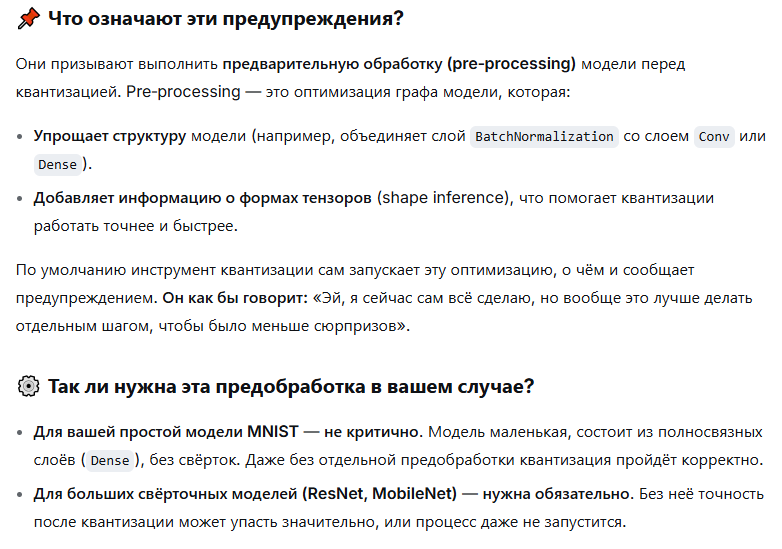

###минималистичный код чтения onnx и инференса одного нормированного изображения

In [14]:
#
# минималистичный чтения onnx и инференса одного нормированного изображения
#
import onnxruntime as ort
# Берем первое изображение
image = test_images[0:1]  # форма (1, 784)
label = test_labels[0]

# Загружаем ONNX модель и делаем предсказание
session = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])
pred = np.argmax(session.run(None, {session.get_inputs()[0].name: image})[0])

# Выводим результат
label, pred

(np.uint8(7), np.int64(7))

#Бенчмарк

In [22]:
# Что делает код:
# - Берёт модели из файлов (Keras грузится один раз, ONNX сессии создаются один раз).
# - Считает размер через os.path.getsize.
# - Считает точность на полном тестовом сете.
# - Бенчмарит инференс: 30 прогонов на случайных срезах данных для каждого batch size, усредняет время в мс.
# - Выводит идеально выровненную таблицу через pandas.

import os, time, pandas as pd, onnxruntime as ort

BATCHES = [1, 8, 32, 64, 128]
RUNS = 30

def bench(model, name, path, is_keras):
    size = os.path.getsize(path) / 1024
    # 🔑 Динамически получаем имя входа (фиксит args_0 / input)
    in_name = None if is_keras else model.get_inputs()[0].name

    # 1. Точность
    feed = test_images if is_keras else {in_name: test_images}
    pred = model.predict(test_images, verbose=0) if is_keras else model.run(None, feed)[0]
    acc = np.mean(np.argmax(pred, axis=1) == test_labels) * 100

    # 2. Скорость
    times = {}
    for bs in BATCHES:
        batch = test_images[:bs]
        # Прогрев
        _ = model.predict(batch, verbose=0) if is_keras else model.run(None, {in_name: batch})[0]
        t0 = time.perf_counter()
        for _ in range(RUNS):
            i = np.random.randint(0, len(test_images) - bs)
            batch = test_images[i:i+bs]
            _ = model.predict(batch, verbose=0) if is_keras else model.run(None, {in_name: batch})[0]
        times[bs] = (time.perf_counter() - t0) * 1000 / RUNS

    return {"Модель": name, "Размер (KB)": f"{size:.1f}", "Точность (%)": f"{acc:.2f}",
            **{f"Batch {b} (мс)": f"{t:.2f}" for b, t in times.items()}}

res = []
# Keras: свежая загрузка с диска vs уже в памяти
m_keras = tf.keras.models.load_model("model.keras")
res.append(bench(tf.keras.models.load_model("model.keras"), "Keras (fresh)", "model.keras", True))
res.append(bench(m_keras, "Keras (pre-loaded)", "model.keras", True))

# ONNX: 3 файла
for n, p in [("ONNX", "model.onnx"), ("ONNX dyn", "model_quantized_dynamic.onnx"), ("ONNX static", "model_quantized_static.onnx")]:
    res.append(bench(ort.InferenceSession(p, providers=["CPUExecutionProvider"]), n, p, False))

# Вывод ровной таблицы
pd.DataFrame(res).set_index('Модель').T

Модель,Keras (fresh),Keras (pre-loaded),ONNX,ONNX dyn,ONNX static
Размер (KB),4795.0,4795.0,1591.2,402.4,403.8
Точность (%),97.47,97.47,97.47,97.45,97.48
Batch 1 (мс),79.08,77.61,0.17,0.07,0.15
Batch 8 (мс),80.73,90.79,0.25,0.18,0.39
Batch 32 (мс),144.09,99.14,0.69,0.52,1.22
Batch 64 (мс),132.86,80.05,1.24,0.94,3.01
Batch 128 (мс),85.20,116.35,2.43,2.60,4.90


In [20]:
import os, time, numpy as np, pandas as pd
import tensorflow as tf
import onnxruntime as ort

BATCHES = [1, 8, 32, 64, 128]
RUNS = 30

def bench(model_ref, name, path, mode):
    size = os.path.getsize(path) / 1024

    if mode == 'keras':
        pred = model_ref.predict(test_images, verbose=0)
        run_fn = lambda b: model_ref.predict(b, verbose=0)
        supports_batch = True

    elif mode == 'keras_jit':
        @tf.function(input_signature=[tf.TensorSpec([None, 784], tf.float32)], jit_compile=True)
        def infer(x): return model_ref(x, training=False)
        infer(tf.zeros((1, 784), tf.float32))
        pred = infer(test_images).numpy()
        run_fn = lambda b: infer(b)
        supports_batch = True

    elif mode == 'onnx':
        sess = model_ref
        inp = sess.get_inputs()[0].name
        pred = sess.run(None, {inp: test_images})[0]
        run_fn = lambda b: sess.run(None, {inp: b})
        supports_batch = True

    elif mode == 'tflite':
        interp = model_ref
        inp_d = interp.get_input_details()[0]
        out_d = interp.get_output_details()[0]
        inp_idx, out_idx = inp_d['index'], out_d['index']
        in_dtype = inp_d['dtype']

        # Точность: 500 сэмплов по одному
        preds = []
        for i in range(500):
            interp.set_tensor(inp_idx, test_images[i:i+1].astype(in_dtype))
            interp.invoke()
            preds.append(interp.get_tensor(out_idx).reshape(1, -1))
        pred = np.vstack(preds)

        # Инференс: эмуляция батча через цикл
        def run_fn(batch):
            outs = []
            for k in range(len(batch)):
                interp.set_tensor(inp_idx, batch[k:k+1].astype(in_dtype))
                interp.invoke()
                outs.append(interp.get_tensor(out_idx).reshape(1, -1))
            return np.vstack(outs) if len(outs) > 1 else outs[0]

        supports_batch = False

    acc = np.mean(np.argmax(pred, axis=1) == test_labels[:len(pred)]) * 100

    times = {}
    for bs in BATCHES:
        run_fn(test_images[:1].astype(np.float32))  # 🔥 Прогрев
        t0 = time.perf_counter()
        for _ in range(RUNS):
            # ✅ ИСПРАВЛЕНО: всегда резервируем bs сэмплов, даже для TFLite
            max_start = len(test_images) - bs
            i = np.random.randint(0, max(1, max_start))

            if supports_batch:
                run_fn(test_images[i:i+bs].astype(np.float32))
            else:
                # Эмуляция батча: bs последовательных инференсов по 1 сэмплу
                for j in range(bs):
                    run_fn(test_images[i+j:i+j+1].astype(np.float32))

        times[bs] = (time.perf_counter() - t0) * 1000 / RUNS

    return {"Модель": name, "Размер (KB)": f"{size:.1f}", "Точность (%)": f"{acc:.2f}",
            **{f"Batch {b} (мс)": f"{t:.2f}" for b, t in times.items()}}

res = []

# 1️⃣ Keras ОБЫЧНЫЙ (первым!)
m = tf.keras.models.load_model("model.keras")
res.append(bench(m, "Keras", "model.keras", "keras"))
res.append(bench(m, "Keras-(jit+tf.function)", "model.keras", "keras_jit"))

# 2️⃣ ONNX
for n, p in [("ONNX", "model.onnx"), ("ONNX-dyn", "model_quantized_dynamic.onnx"), ("ONNX-static", "model_quantized_static.onnx")]:
    res.append(bench(ort.InferenceSession(p, providers=["CPUExecutionProvider"]), n, p, "onnx"))

# 3️⃣ TFLite
for n, p in [("TFLite-FP32", "model_float32.tflite"), ("TFLite-FP16", "model_float16.tflite"),
             ("TFLite-Dyn-Int8", "model_dynamic_int8.tflite"), ("TFLite-Full-Int8", "model_full_int8.tflite")]:
    interp = tf.lite.Interpreter(model_path=p)
    interp.allocate_tensors()
    res.append(bench(interp, n, p, "tflite"))

# 📊 Итоговая таблица
pd.DataFrame(res).set_index('Модель').T

Модель,Keras,Keras-(jit+tf.function),ONNX,ONNX-dyn,ONNX-static,TFLite-FP32,TFLite-FP16,TFLite-Dyn-Int8,TFLite-Full-Int8
Размер (KB),4795.0,4795.0,1591.2,402.4,403.8,1591.7,797.2,406.9,413.2
Точность (%),97.53,97.53,97.53,97.50,97.47,98.20,98.20,98.20,11.00
Batch 1 (мс),71.18,0.92,0.16,0.05,0.06,0.08,0.08,0.03,0.06
Batch 8 (мс),181.85,4.10,0.24,0.12,0.13,0.56,0.54,0.22,0.32
Batch 32 (мс),65.72,6.63,0.53,0.37,0.38,2.55,2.11,1.01,1.32
Batch 64 (мс),70.94,7.11,0.85,0.77,0.74,4.39,4.24,2.73,2.69
Batch 128 (мс),75.95,8.77,1.94,1.31,1.57,8.60,8.50,6.38,5.19


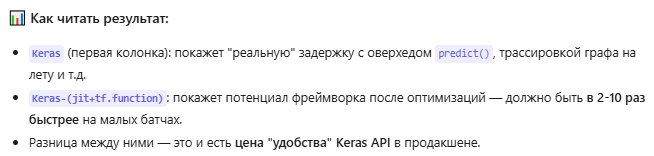

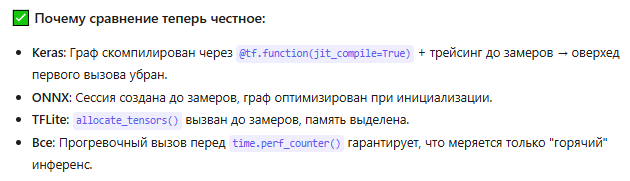